<a href="https://colab.research.google.com/github/AI-is-out-there/2026-REA-Diploma-Practical-Part/blob/main/FireCrawl-CR-site-parsing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# 1. Install the latest version of Firecrawl
!pip install firecrawl-py --upgrade -q

from firecrawl import Firecrawl

In [16]:
API_KEY = 'fc-7f29fdf62edf482c9bd1a65cbcb4eb78'

In [18]:
app = Firecrawl(api_key=API_KEY)


In [21]:
from firecrawl import Firecrawl
import re
import networkx as nx
import matplotlib.pyplot as plt


def fetch_doctor_actions_graph_firecrawl_interact(clinical_registry_id: str):
    """
    Fetches clinical registry details from minzdrav using Firecrawl's AI interaction
    and visualizes doctor actions as a graph.

    Args:
        clinical_registry_id: The ID of the clinical registry entry (e.g., '270_3')

    Returns:
        NetworkX DiGraph representing the doctor's action flow
    """
    api_key = ''  # Replace with your actual API key
    app = Firecrawl(api_key=api_key)

    base_url = f"https://cr.minzdrav.gov.ru/view-cr/{clinical_registry_id}"

    print(f"🔍 Fetching data for Clinical Registry ID: {clinical_registry_id}")
    print(f"🌐 URL: {base_url}")

    try:
        # 1. Initial scrape to start the browser session and get a scrape_id
        print("🌐 Opening the clinical registry page...")
        result = app.scrape(base_url, formats=["markdown"])

        # Extract the session ID
        if hasattr(result, 'metadata') and hasattr(result.metadata, 'scrape_id'):
            scrape_id = result.metadata.scrape_id
        elif isinstance(result, dict) and 'metadata' in result:
            scrape_id = result['metadata'].get('scrape_id') or result['metadata'].get('scrapeId')
        else:
            print("❌ Could not find scrape_id in the response.")
            return None, clinical_registry_id

        print(f"✅ Browser session started. ID: {scrape_id}")

        # 2. AI Action: Navigate to Appendix B and extract the text
        print("📑 AI Agent is finding and extracting 'Doctor's Action Algorithms' (Appendix B)...")
        response = app.interact(
            scrape_id,
            prompt=(
                "Find the section titled 'Приложение Б' or 'Алгоритмы действий врача' (Doctor's Action Algorithms). "
                "Click on it to expand it if it is collapsed. "
                "Then, extract and return the full text content of this specific section. "
                "Do not summarize it, return the exact text."
            )
        )

        # The AI agent returns the extracted text in the 'output' field
        extracted_text = response.output
        print("✅ Successfully extracted the Doctor's Actions Algorithm!")

        # Display the raw content
        print("\n📄 RAW EXTRACTED CONTENT FROM FIRECRAWL INTERACT:")
        print("="*80)
        lines = extracted_text.split('\n')
        print(f"Total lines in document: {len(lines)}")
        print(f"Total characters: {len(extracted_text)}")
        print("\nFirst 50 lines of content:")
        for i, line in enumerate(lines[:50]):
            if line.strip():  # Only show non-empty lines
                print(f"{i+1:3d}: {line[:100]}{'...' if len(line) > 100 else ''}")

        if len(lines) > 50:
            print(f"\n... and {len(lines) - 50} more lines")

        print("="*80)

        # Process the text to identify steps and decisions
        steps = extract_steps_from_text(extracted_text)

        # Create graph
        G = create_action_graph(steps)

        print(f"✅ Successfully created graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

        # 3. Clean up the browser session to save credits
        app.stop_interaction(scrape_id)
        print("🧹 Browser session closed.")

        return G, clinical_registry_id

    except Exception as e:
        print(f"❌ An error occurred: {e}")
        import traceback
        traceback.print_exc()
        return None, clinical_registry_id


def extract_steps_from_text(text_content):
    """
    Extracts steps and decisions from the clinical registry text.
    """
    # Clean up text - split into meaningful chunks
    lines = [line.strip() for line in text_content.split('\n') if line.strip()]

    steps = []
    step_number = 0

    # Pattern matching for common Russian medical step indicators
    step_patterns = [
        r'^\d+[.)]\s+',  # Numbers followed by . or )
        r'^[А-Яа-яA-Za-z]+\s*\d+[.)]\s+',  # Letter-number combinations
        r'^•\s+',  # Bullet points
        r'^-\s+',  # Dash points
        r'^[IVX]+[.)]\s+',  # Roman numerals
        r'^[А-Яа-я]{1,2}[.)]\s+',  # Single Cyrillic letters
    ]

    decision_keywords = [
        'если', 'при', 'в случае', 'когда', 'наличии', 'отсутствии',
        'if', 'when', 'in case', 'при наличии', 'при отсутствии',
        'следует', 'необходимо', 'назначить', 'провести', 'осмотреть',
        'should', 'must', 'need', 'perform', 'examine', 'prescribe'
    ]

    # More specific patterns for doctor actions
    action_keywords = [
        'следует', 'необходимо', 'назначить', 'провести', 'осмотреть', 'наблюдать', 'лечить', 'диагностировать',
        'should', 'must', 'need', 'perform', 'examine', 'prescribe', 'treat', 'diagnose'
    ]

    # Identify potential algorithm sections
    algo_start_patterns = [
        r'Приложение\s*[БB]',
        r'Алгоритмы?\s+действий?\s+врача',
        r'Действия\s+врача',
        r'Алгоритм\s+действий?',
        r'Protocol',
        r'Procedure'
    ]

    in_algorithm_section = False

    for i, line in enumerate(lines):
        # Check if we've entered an algorithm section
        line_lower = line.lower()
        if any(re.search(pattern, line, re.IGNORECASE) for pattern in algo_start_patterns):
            in_algorithm_section = True
            continue

        # If we're not in algorithm section yet, continue
        if not in_algorithm_section:
            continue

        # Skip very short lines that might be headers
        if len(line) < 15:
            continue

        # Check if this line starts a new step based on patterns
        is_new_step = any(re.match(pattern, line) for pattern in step_patterns)

        # Check if this line contains an action or decision
        has_action = any(keyword in line_lower for keyword in action_keywords)
        has_decision = any(keyword in line_lower for keyword in decision_keywords)

        # If we detect an action/decision or the line matches step pattern, process it
        if is_new_step or has_action or has_decision:
            # Clean the line from step indicators
            cleaned_line = line
            for pattern in step_patterns:
                cleaned_line = re.sub(pattern, '', cleaned_line, count=1)

            if cleaned_line.strip():  # Only add non-empty steps
                step_number += 1
                steps.append({
                    'id': step_number,
                    'text': cleaned_line.strip(),
                    'is_decision': has_decision,
                    'type': 'decision' if has_decision else 'action'
                })
        elif has_action or has_decision:
            # Even if not explicitly numbered, if it contains action keywords, add it
            step_number += 1
            steps.append({
                'id': step_number,
                'text': line.strip(),
                'is_decision': has_decision,
                'type': 'decision' if has_decision else 'action'
            })

    # If no steps were found in algorithm section, try a broader search
    if not steps:
        # Look for sentences containing action keywords in the entire text
        # Split by common sentence endings
        sentences = re.split(r'[.!?;]+', text_content)
        for sentence in sentences:
            sentence = sentence.strip()
            if len(sentence) > 25:  # Only consider substantial sentences
                has_action = any(keyword in sentence.lower() for keyword in action_keywords)
                has_decision = any(keyword in sentence.lower() for keyword in decision_keywords)

                if has_action or has_decision:
                    step_number += 1
                    steps.append({
                        'id': step_number,
                        'text': sentence,
                        'is_decision': has_decision,
                        'type': 'decision' if has_decision else 'action'
                    })

    # If still no steps, do a final broad scan for any content that looks like instructions
    if not steps:
        for line in lines:
            if len(line) > 30:  # Substantial content
                has_action = any(keyword in line.lower() for keyword in action_keywords)
                has_decision = any(keyword in line.lower() for keyword in decision_keywords)

                if has_action or has_decision or '–' in line or ':' in line:
                    step_number += 1
                    steps.append({
                        'id': step_number,
                        'text': line,
                        'is_decision': has_decision,
                        'type': 'decision' if has_decision else 'action'
                    })

    return steps


def create_action_graph(steps):
    """
    Creates a NetworkX graph from the extracted steps.
    """
    G = nx.DiGraph()

    if not steps:
        return G

    # Add nodes
    for step in steps:
        G.add_node(step['id'],
                  label=step['text'][:50] + "..." if len(step['text']) > 50 else step['text'],
                  full_text=step['text'],
                  type=step['type'])

    # Add edges - connect sequentially
    for i in range(len(steps) - 1):
        G.add_edge(steps[i]['id'], steps[i+1]['id'])

    return G


def visualize_action_graph(G, clinical_registry_id):
    """
    Visualizes the doctor's action graph.
    """
    if not G or G.number_of_nodes() == 0:
        print("No graph to visualize - no steps found in the clinical registry")
        return

    plt.figure(figsize=(16, 10))

    # Position nodes using spring layout
    pos = nx.spring_layout(G, k=3, iterations=50)

    # Separate nodes by type for different coloring
    action_nodes = [node for node, attr in G.nodes(data=True) if attr['type'] == 'action']
    decision_nodes = [node for node, attr in G.nodes(data=True) if attr['type'] == 'decision']

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=action_nodes, node_color='lightblue',
                          node_size=2500, alpha=0.8, label='Action Step')
    nx.draw_networkx_nodes(G, pos, nodelist=decision_nodes, node_color='orange',
                          node_size=2500, alpha=0.8, label='Decision Point')

    # Draw edges
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray', arrows=True, arrowsize=20)

    # Draw labels with word wrapping for better readability
    labels = {}
    for node_id in G.nodes():
        original_label = G.nodes[node_id]['label']
        # Wrap long labels
        wrapped_label = '\n'.join([original_label[i:i+20] for i in range(0, len(original_label), 20)])
        labels[node_id] = wrapped_label

    nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold')

    # Add legend
    plt.legend(loc='upper right')

    plt.title(f"Doctor's Action Algorithm for Clinical Registry ID: {clinical_registry_id}", size=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print detailed information
    print(f"\n📋 Detailed Action Steps for Clinical Registry ID: {clinical_registry_id}")
    print("=" * 80)
    for node_id in sorted(G.nodes()):
        node_data = G.nodes[node_id]
        print(f"{node_id}. [{node_data['type'].upper()}]")
        print(f"   {node_data['full_text'][:200]}{'...' if len(node_data['full_text']) > 200 else ''}")
        print("-" * 40)


def main():
    """
    Main function to run the clinical registry action analyzer using Firecrawl Interact.
    """
    print("🏥 Clinical Registry Doctor Action Analyzer (Firecrawl Interact Method)")
    print("="*80)
    print("This tool uses Firecrawl's AI interaction to access Russian Ministry of Health clinical registries")
    print("and visualizes doctor's action algorithms as graphs.")
    print("="*80)

    # Get user input for clinical registry ID
    while True:
        clinical_registry_id = input("\nEnter Clinical Registry ID (e.g., '270_3', '145'): ").strip()

        if not clinical_registry_id:
            print("⚠️  No ID provided. Please enter a valid Clinical Registry ID.")
            continue

        break

    print(f"\n🚀 Starting analysis for Clinical Registry ID: {clinical_registry_id}")

    # Fetch and process using Firecrawl Interact
    G, cid = fetch_doctor_actions_graph_firecrawl_interact(clinical_registry_id)

    if G and G.number_of_nodes() > 0:
        # Visualize the graph
        visualize_action_graph(G, cid)

        # Additional analysis
        print(f"\n📊 Graph Analysis Summary:")
        print(f"   • Total Steps: {G.number_of_nodes()}")
        print(f"   • Total Transitions: {G.number_of_edges()}")
        print(f"   • Action Steps: {len([n for n, d in G.nodes(data=True) if d['type'] == 'action'])}")
        print(f"   • Decision Points: {len([n for n, d in G.nodes(data=True) if d['type'] == 'decision'])}")

        # Check if graph is connected
        if G.number_of_nodes() > 1:
            if nx.is_weakly_connected(G):
                print("   • Flow: Sequential path exists through all steps")
            else:
                print("   • Flow: Multiple disconnected paths detected")
        else:
            print("   • Flow: Single step detected")

        return G
    else:
        print(f"❌ No actionable steps found for Clinical Registry ID: {clinical_registry_id}")
        print("💡 Possible reasons:")
        print("   • Invalid Firecrawl API key")
        print("   • Content is not publicly accessible")
        print("   • Page structure changed")
        print("   • No algorithmic steps in the registry")
        print("   • AI agent failed to locate the required section")
        return None


if __name__ == "__main__":
    main()

🏥 Clinical Registry Doctor Action Analyzer (Firecrawl Interact Method)
This tool uses Firecrawl's AI interaction to access Russian Ministry of Health clinical registries
and visualizes doctor's action algorithms as graphs.

Enter Clinical Registry ID (e.g., '270_3', '145'): 270_3

🚀 Starting analysis for Clinical Registry ID: 270_3
🔍 Fetching data for Clinical Registry ID: 270_3
🌐 URL: https://cr.minzdrav.gov.ru/view-cr/270_3
🌐 Opening the clinical registry page...
❌ An error occurred: Unauthorized: Failed to scrape. Unauthorized: Invalid token - No additional error details provided.
❌ No actionable steps found for Clinical Registry ID: 270_3
💡 Possible reasons:
   • Invalid Firecrawl API key
   • Content is not publicly accessible
   • Page structure changed
   • No algorithmic steps in the registry
   • AI agent failed to locate the required section


Traceback (most recent call last):
  File "/tmp/ipykernel_3314/1368946266.py", line 29, in fetch_doctor_actions_graph_firecrawl_interact
    result = app.scrape(base_url, formats=["markdown"])
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/firecrawl/v2/client.py", line 217, in scrape
    return scrape_module.scrape(self.http_client, url, options)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/firecrawl/v2/methods/scrape.py", line 61, in scrape
    handle_response_error(response, "scrape")
  File "/usr/local/lib/python3.12/dist-packages/firecrawl/v2/utils/error_handler.py", line 89, in handle_response_error
    raise UnauthorizedError(message, response.status_code, response)
firecrawl.v2.utils.error_handler.UnauthorizedError: Unauthorized: Failed to scrape. Unauthorized: Invalid token - No additional error details provided.


# Part II

In [ ]:
from firecrawl import Firecrawl
import re

API_KEY = 'fc-7f29fdf62edf482c9bd1a65cbcb4eb78'
app = Firecrawl(api_key=API_KEY)


def search_and_extract_with_ai(keyword: str):
    """
    AI-powered RPA workflow:
    1. Open https://cr.minzdrav.gov.ru/clin-rec
    2. Type keyword into search field under "Наименование"
    3. Click first result row → get CR ID *directly from the 'ID' column cell*
    4. Navigate to /preview-cr/{ID}#doc_b
    5. Extract full text of "Приложение Б"

    ID is extracted as raw string (preserving underscores, hyphens, prefixes).
    """
    print(f"\n🔍 Starting Firecrawl AI session for: '{keyword}'")

    try:
        # 1. Open registry
        print("🌐 Opening clinical guidelines registry...")
        result = app.scrape("https://cr.minzdrav.gov.ru/clin-rec", formats=["markdown"])

        # Extract scrape_id robustly
        scrape_id = None
        if hasattr(result, 'metadata') and hasattr(result.metadata, 'scrape_id'):
            scrape_id = result.metadata.scrape_id
        elif isinstance(result, dict) and 'metadata' in result:
            scrape_id = result['metadata'].get('scrape_id') or result['metadata'].get('scrapeId')
        if not scrape_id:
            raise RuntimeError("❌ No scrape_id in initial response")

        print(f"✅ Browser session started. ID: {scrape_id}")

        # 2. AI: Type into search field under "Наименование"
        print(f"🔎 AI Agent typing '{keyword}' into the 'Наименование' filter...")
        app.interact(
            scrape_id,
            prompt=f"Locate the search input under the table header 'Наименование', type '{keyword}', and press Enter to filter."
        )

        # 3. AI: Click first result row → then extract ID from the *ID column cell* (leftmost)
        print("🆔 AI Agent extracting CR ID from first row's 'ID' column (raw string)...")
        id_response = app.interact(
            scrape_id,
            prompt=("""\
                The filtered table is loaded. Locate the first data row.
                Find the cell directly under the column header 'ID' (typically the leftmost column).
                Extract the *exact text content* of that cell — it may contain digits, underscores, hyphens, or letters (e.g., '230_3', '145').
                Return ONLY that raw string, no extra characters, no explanations.
                """
            )
        )
        raw_id = id_response.output.strip()

        # Sanitize: remove common noise (quotes, brackets, surrounding whitespace)
        raw_id = re.sub(r'^[\'"`\[\{]+|[\'"`\]\}]+$', '', raw_id)  # strip quotes/brackets
        cr_id = raw_id.strip()
        if not cr_id:
            raise ValueError("Empty ID extracted after cleaning")

        print(f"✅ Extracted CR ID (raw): '{cr_id}'")

        # 4. Navigate to Appendix B
        preview_url = f"https://cr.minzdrav.gov.ru/preview-cr/{cr_id}#doc_b"
        print(f"➡️ Loading: {preview_url}")
        _ = app.scrape(preview_url, formats=["markdown"])  # ensure anchor loads

        # 5. AI: Extract full text of "Приложение Б"
        print("📑 AI Agent extracting 'Приложение Б' (Doctor's Action Algorithm)...")
        algo_response = app.interact(
            scrape_id,
            prompt=(
                "Find the section titled 'Приложение Б' or 'Алгоритмы действий врача'. "
                "If collapsed, expand it. Then select and return the FULL visible text content — verbatim, no summarization. "
                "Only return the raw text."
            )
        )
        extracted_text = algo_response.output.strip()
        if not extracted_text:
            raise RuntimeError("❌ Empty algorithm text returned")

        print("✅ Successfully extracted Doctor's Action Algorithm!")

        # 6. Cleanup
        app.stop_interaction(scrape_id)
        print("🧹 Browser session closed.")

        return {
            "original_input": keyword,
            "cr_id": cr_id,
            "algorithm_text": extracted_text,
            "status": "success"
        }

    except Exception as e:
        print(f"❌ Error: {type(e).__name__}: {e}")
        if 'scrape_id' in locals():
            try:
                app.stop_interaction(scrape_id)
            except:
                pass
        return {
            "original_input": keyword,
            "error": str(e),
            "status": "failed"
        }


# === MAIN EXECUTION ===
if __name__ == "__main__":
    kw = input("Enter CR title (e.g., 'Прогрессирующая мышечная дистрофия'): ").strip()
    if not kw:
        print("⚠️ Empty input. Exiting.")
        exit(1)

    res = search_and_extract_with_ai(kw)

    print("\n" + "="*80)
    print("FIRECRAWL CR EXTRACTION RESULT")
    print("="*80)
    print(f"Input:          {res['original_input']}")
    if res['status'] == 'success':
        print(f"CR ID (raw):    '{res['cr_id']}'")  # preserves format: 230_3, 145-7, etc.
        print(f"Algorithm len:  {len(res['algorithm_text'])} chars")
        print("\nFirst 300 chars of Algorithm:")
        print(repr(res['algorithm_text'][:300] + ("..." if len(res['algorithm_text']) > 300 else "")))
    else:
        print(f"Error:          {res['error']}")
    print("="*80)

Enter CR title (e.g., 'Прогрессирующая мышечная дистрофия'): Болезнь Грейвса

🔍 Starting Firecrawl AI session for: 'Болезнь Грейвса'
🌐 Opening clinical guidelines registry...
✅ Browser session started. ID: 019f03ab-75e6-75eb-832d-8adf8761f478
🔎 AI Agent typing 'Болезнь Грейвса' into the 'Наименование' filter...
🆔 AI Agent extracting CR ID from first row's 'ID' column (raw string)...
✅ Extracted CR ID (raw): '270_3'
➡️ Loading: https://cr.minzdrav.gov.ru/preview-cr/270_3#doc_b
📑 AI Agent extracting 'Приложение Б' (Doctor's Action Algorithm)...
✅ Successfully extracted Doctor's Action Algorithm!
🧹 Browser session closed.

FIRECRAWL CR EXTRACTION RESULT
Input:          Болезнь Грейвса
CR ID (raw):    '270_3'
Algorithm len:  227 chars

First 300 chars of Algorithm:
'Алгоритмы действий врача\nГлавная\n/\nАлгоритмы действия врача\nАлгоритмы действий врача\nID\tНаименование\n\n\t\n\n569_2\tЖелудочковые нарушения ритма сердца. Внезапная сердечная смерть.\n574_1\tРак желудка\nСтрок на странице:

# Part III

🏥 Clinical Registry Doctor Action Analyzer (Firecrawl Interact Method)
This tool uses Firecrawl's AI interaction to access Russian Ministry of Health clinical registries
and visualizes doctor's action algorithms as graphs.

Enter Clinical Registry ID (e.g., '270_3', '145'): 270_3

🚀 Starting analysis for Clinical Registry ID: 270_3
🔍 Fetching data for Clinical Registry ID: 270_3
🌐 URL: https://cr.minzdrav.gov.ru/view-cr/270_3
🌐 Opening the clinical registry page...
✅ Browser session started. ID: 019f0476-65cd-719c-84b8-dd0d524b72cb
📑 AI Agent is finding and extracting 'Doctor's Action Algorithms' (Appendix B)...
⚠️ AI agent returned empty or invalid response
🔄 Attempting to extract all page content...
✅ Successfully extracted content!

📄 RAW EXTRACTED CONTENT FROM FIRECRAWL INTERACT:
Total lines in document: 368
Total characters: 24287

First 50 lines of content:
  1: tool_code
  2: print(default_api.browser(code='agent-browser get text @e16 && agent-browser get text @e17 && agent-...


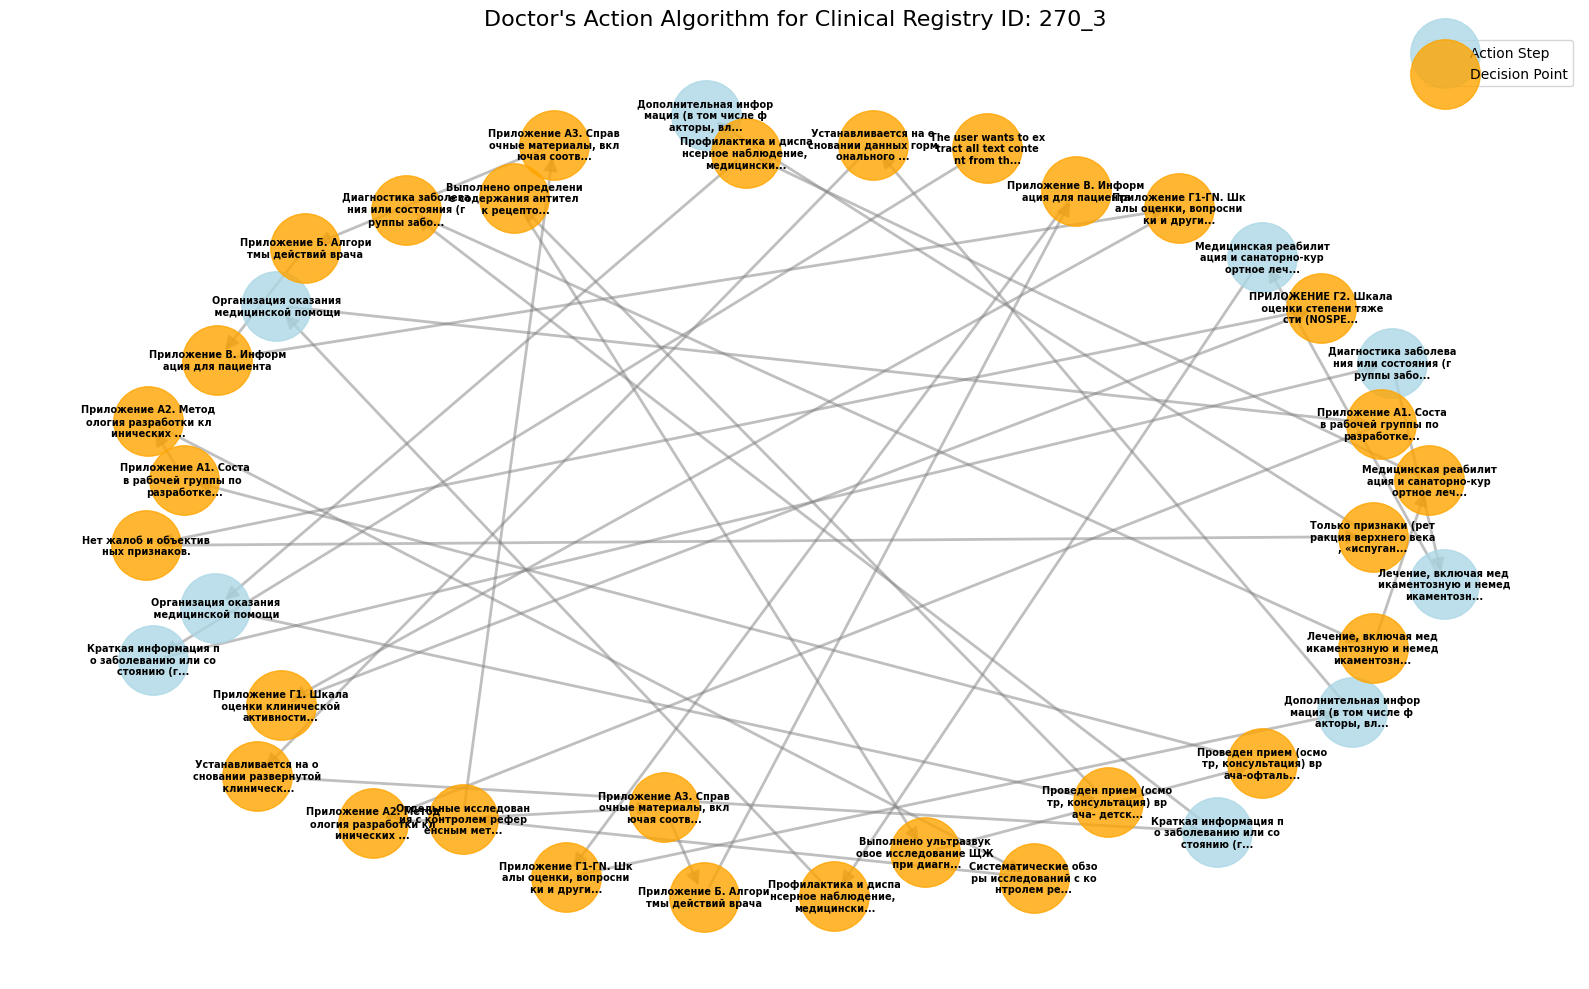


📋 Detailed Action Steps for Clinical Registry ID: 270_3
1. [DECISION]
   The user wants to extract all text content from the current page. I have identified all the text elements and will use `agent-browser get text` to extract their content. I will then combine all the ex...
----------------------------------------
2. [ACTION]
   Краткая информация по заболеванию или состоянию (группы заболеваний или состояний)
----------------------------------------
3. [ACTION]
   Диагностика заболевания или состояния (группы заболеваний или состояний) медицинские показания и
----------------------------------------
4. [ACTION]
   Лечение, включая медикаментозную и немедикаментозную терапии, диетотерапию, обезболивание, медици
----------------------------------------
5. [ACTION]
   Медицинская реабилитация и санаторно-курортное лечение, медицинские показания и противопоказания
----------------------------------------
6. [DECISION]
   Профилактика и диспансерное наблюдение, медицинские показания и п

In [25]:
from firecrawl import Firecrawl
import re
import networkx as nx
import matplotlib.pyplot as plt


def fetch_doctor_actions_graph_firecrawl_interact(clinical_registry_id: str):
    """
    Fetches clinical registry details from minzdrav using Firecrawl's AI interaction
    and visualizes doctor actions as a graph.

    Args:
        clinical_registry_id: The ID of the clinical registry entry (e.g., '270_3')

    Returns:
        NetworkX DiGraph representing the doctor's action flow
    """
    api_key = 'fc-7f29fdf62edf482c9bd1a65cbcb4eb78'

    app = Firecrawl(api_key=api_key)

    base_url = f"https://cr.minzdrav.gov.ru/view-cr/{clinical_registry_id}"

    print(f"🔍 Fetching data for Clinical Registry ID: {clinical_registry_id}")
    print(f"🌐 URL: {base_url}")

    try:
        # 1. Initial scrape to start the browser session and get a scrape_id
        print("🌐 Opening the clinical registry page...")
        result = app.scrape(base_url, formats=["markdown"])

        # Extract the session ID
        if hasattr(result, 'metadata') and hasattr(result.metadata, 'scrape_id'):
            scrape_id = result.metadata.scrape_id
        elif isinstance(result, dict) and 'metadata' in result:
            scrape_id = result['metadata'].get('scrape_id') or result['metadata'].get('scrapeId')
        else:
            print("❌ Could not find scrape_id in the response.")
            return None, clinical_registry_id

        print(f"✅ Browser session started. ID: {scrape_id}")

        # 2. AI Action: Navigate to Appendix B and extract the text
        print("📑 AI Agent is finding and extracting 'Doctor's Action Algorithms' (Appendix B)...")
        response = app.interact(
            scrape_id,
            prompt=(
                "Find the section titled 'Приложение Б' or 'Алгоритмы действий врача' (Doctor's Action Algorithms). "
                "Click on it to expand it if it is collapsed. "
                "Then, extract and return the full text content of this specific section. "
                "Do not summarize it, return the exact text."
            )
        )

        # The AI agent returns the extracted text in the 'output' field
        extracted_text = response.output if response and hasattr(response, 'output') else None

        if not extracted_text:
            print("⚠️ AI agent returned empty or invalid response")
            # Try alternative approach - extract all content from the page
            print("🔄 Attempting to extract all page content...")
            alt_response = app.interact(
                scrape_id,
                prompt="Extract all text content from the current page. Return the full text without summarization."
            )
            extracted_text = alt_response.output if alt_response and hasattr(alt_response, 'output') else None

        if not extracted_text:
            print("❌ Failed to extract any content from the page")
            app.stop_interaction(scrape_id)
            return None, clinical_registry_id

        print("✅ Successfully extracted content!")

        # Display the raw content
        print("\n📄 RAW EXTRACTED CONTENT FROM FIRECRAWL INTERACT:")
        print("="*80)
        lines = extracted_text.split('\n')
        print(f"Total lines in document: {len(lines)}")
        print(f"Total characters: {len(extracted_text)}")
        print("\nFirst 50 lines of content:")
        for i, line in enumerate(lines[:50]):
            if line.strip():  # Only show non-empty lines
                print(f"{i+1:3d}: {line[:100]}{'...' if len(line) > 100 else ''}")

        if len(lines) > 50:
            print(f"\n... and {len(lines) - 50} more lines")

        print("="*80)

        # Process the text to identify steps and decisions
        steps = extract_steps_from_markdown(extracted_text)

        # Create graph
        G = create_action_graph_improved(steps)

        print(f"✅ Successfully created graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

        # 3. Clean up the browser session to save credits
        app.stop_interaction(scrape_id)
        print("🧹 Browser session closed.")

        return G, clinical_registry_id

    except Exception as e:
        print(f"❌ An error occurred: {e}")
        import traceback
        traceback.print_exc()
        # Ensure cleanup in case of error
        try:
            if 'scrape_id' in locals():
                app.stop_interaction(scrape_id)
        except:
            pass
        return None, clinical_registry_id


def extract_steps_from_markdown(markdown_content):
    """
    Extracts steps and decisions from the clinical registry markdown content.
    """
    steps = []
    step_number = 0

    # Define patterns for identifying different types of content
    step_patterns = [
        r'^\d+[.)]\s+(.+)',  # Numbered lists
        r'^[А-Яа-яA-Za-z]+\s*\d+[.)]\s+(.+)',  # Letter-number combinations
        r'^•\s+(.+)',  # Bullet points
        r'^-\s+(.+)',  # Dash points
        r'^[IVX]+[.)]\s+(.+)',  # Roman numerals
        r'^[А-Яа-я]{1,2}[.)]\s+(.+)',  # Single Cyrillic letters
    ]

    decision_keywords = [
        'если', 'при', 'в случае', 'когда', 'наличии', 'отсутствии',
        'if', 'when', 'in case', 'при наличии', 'при отсутствии',
        'следует', 'необходимо', 'назначить', 'провести', 'осмотреть',
        'should', 'must', 'need', 'perform', 'examine', 'prescribe'
    ]

    action_keywords = [
        'следует', 'необходимо', 'назначить', 'провести', 'осмотреть', 'наблюдать', 'лечить', 'диагностировать',
        'should', 'must', 'need', 'perform', 'examine', 'prescribe', 'treat', 'diagnose'
    ]

    # Split content into lines
    lines = markdown_content.split('\n')

    # Process markdown content to extract structured information
    current_item = ""
    item_type = 'other'

    for i, line in enumerate(lines):
        line = line.strip()

        # Skip empty lines
        if not line:
            continue

        # Check if this line starts a new step based on patterns
        is_new_step = False
        matched_text = ""

        for pattern in step_patterns:
            match = re.match(pattern, line)
            if match:
                is_new_step = True
                matched_text = match.group(1).strip()
                break

        if is_new_step:
            # Process previous item if exists
            if current_item:
                has_action = any(keyword in current_item.lower() for keyword in action_keywords)
                has_decision = any(keyword in current_item.lower() for keyword in decision_keywords)

                step_number += 1
                steps.append({
                    'id': step_number,
                    'text': current_item,
                    'is_decision': has_decision,
                    'type': 'decision' if has_decision else 'action'
                })

            # Start new item
            current_item = matched_text
            has_action = any(keyword in current_item.lower() for keyword in action_keywords)
            has_decision = any(keyword in current_item.lower() for keyword in decision_keywords)
            item_type = 'decision' if has_decision else 'action'

        else:
            # Check if line contains action/decision keywords even if not in a list
            has_action = any(keyword in line.lower() for keyword in action_keywords)
            has_decision = any(keyword in line.lower() for keyword in decision_keywords)

            if has_action or has_decision:
                # This line seems to be an important step
                step_number += 1
                steps.append({
                    'id': step_number,
                    'text': line,
                    'is_decision': has_decision,
                    'type': 'decision' if has_decision else 'action'
                })

    # Add the last item if exists
    if current_item:
        has_action = any(keyword in current_item.lower() for keyword in action_keywords)
        has_decision = any(keyword in current_item.lower() for keyword in decision_keywords)

        step_number += 1
        steps.append({
            'id': step_number,
            'text': current_item,
            'is_decision': has_decision,
            'type': 'decision' if has_decision else 'action'
        })

    # If no steps were found using patterns, try a broader approach
    if not steps:
        # Look for content that might be structured differently
        # Split by double newlines which often separate sections
        sections = re.split(r'\n\s*\n', markdown_content)

        for section in sections:
            section = section.strip()
            if len(section) > 50:  # Only consider substantial sections
                has_action = any(keyword in section.lower() for keyword in action_keywords)
                has_decision = any(keyword in section.lower() for keyword in decision_keywords)

                if has_action or has_decision:
                    step_number += 1
                    steps.append({
                        'id': step_number,
                        'text': section[:200] + "..." if len(section) > 200 else section,
                        'is_decision': has_decision,
                        'type': 'decision' if has_decision else 'action'
                    })

    # If still no steps, try to identify by markdown headers and content structure
    if not steps:
        # Look for content after headers that might indicate algorithm sections
        header_pattern = r'^(#+)\s+(.*)$'
        lines = markdown_content.split('\n')

        in_algorithm_section = False
        for line in lines:
            # Check if this is a header
            header_match = re.match(header_pattern, line)
            if header_match:
                header_level = len(header_match.group(1))
                header_text = header_match.group(2).lower()

                # Check if this header indicates an algorithm section
                if any(keyword in header_text for keyword in ['алгоритм', 'действия врача', 'приложение б', 'protocol', 'procedure']):
                    in_algorithm_section = True
                    continue
                elif header_level <= 2:  # Major section change
                    in_algorithm_section = False

            elif in_algorithm_section:
                # This content is within an algorithm section
                if len(line.strip()) > 20:
                    has_action = any(keyword in line.lower() for keyword in action_keywords)
                    has_decision = any(keyword in line.lower() for keyword in decision_keywords)

                    if has_action or has_decision:
                        step_number += 1
                        steps.append({
                            'id': step_number,
                            'text': line.strip(),
                            'is_decision': has_decision,
                            'type': 'decision' if has_decision else 'action'
                        })

    # If still no steps, try to find any content with medical action keywords
    if not steps:
        sentences = re.split(r'[.!?;]+', markdown_content)
        for sentence in sentences:
            sentence = sentence.strip()
            if len(sentence) > 25:  # Only consider substantial sentences
                has_action = any(keyword in sentence.lower() for keyword in action_keywords)
                has_decision = any(keyword in sentence.lower() for keyword in decision_keywords)

                if has_action or has_decision:
                    step_number += 1
                    steps.append({
                        'id': step_number,
                        'text': sentence,
                        'is_decision': has_decision,
                        'type': 'decision' if has_decision else 'action'
                    })

    return steps


def create_action_graph_improved(steps):
    """
    Creates a NetworkX graph from the extracted steps with improved logic.
    """
    G = nx.DiGraph()

    if not steps:
        return G

    # Add nodes
    for step in steps:
        G.add_node(step['id'],
                  label=step['text'][:50] + "..." if len(step['text']) > 50 else step['text'],
                  full_text=step['text'],
                  type=step['type'])

    # Add edges - connect sequentially
    for i in range(len(steps) - 1):
        G.add_edge(steps[i]['id'], steps[i+1]['id'])

    # Additionally, look for conditional connections based on keywords
    for i, step_i in enumerate(steps):
        for j, step_j in enumerate(steps[i+1:], i+1):
            # Look for conditional relationships
            if 'если' in step_i['text'].lower() and j == i+1:
                # Direct sequence after conditional
                continue
            elif any(word in step_j['text'].lower() for word in ['тогда', 'следовательно', 'далее']):
                # Explicit connection
                G.add_edge(step_i['id'], step_j['id'])

    return G


def visualize_action_graph(G, clinical_registry_id):
    """
    Visualizes the doctor's action graph.
    """
    if not G or G.number_of_nodes() == 0:
        print("No graph to visualize - no steps found in the clinical registry")
        return

    plt.figure(figsize=(16, 10))

    # Position nodes using spring layout
    pos = nx.spring_layout(G, k=3, iterations=50)

    # Separate nodes by type for different coloring
    action_nodes = [node for node, attr in G.nodes(data=True) if attr['type'] == 'action']
    decision_nodes = [node for node, attr in G.nodes(data=True) if attr['type'] == 'decision']

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=action_nodes, node_color='lightblue',
                          node_size=2500, alpha=0.8, label='Action Step')
    nx.draw_networkx_nodes(G, pos, nodelist=decision_nodes, node_color='orange',
                          node_size=2500, alpha=0.8, label='Decision Point')

    # Draw edges
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray', arrows=True, arrowsize=20)

    # Draw labels with word wrapping for better readability
    labels = {}
    for node_id in G.nodes():
        original_label = G.nodes[node_id]['label']
        # Wrap long labels
        wrapped_label = '\n'.join([original_label[i:i+20] for i in range(0, len(original_label), 20)])
        labels[node_id] = wrapped_label

    nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold')

    # Add legend
    plt.legend(loc='upper right')

    plt.title(f"Doctor's Action Algorithm for Clinical Registry ID: {clinical_registry_id}", size=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print detailed information
    print(f"\n📋 Detailed Action Steps for Clinical Registry ID: {clinical_registry_id}")
    print("=" * 80)
    for node_id in sorted(G.nodes()):
        node_data = G.nodes[node_id]
        print(f"{node_id}. [{node_data['type'].upper()}]")
        print(f"   {node_data['full_text'][:200]}{'...' if len(node_data['full_text']) > 200 else ''}")
        print("-" * 40)


def main():
    """
    Main function to run the clinical registry action analyzer using Firecrawl Interact.
    """
    print("🏥 Clinical Registry Doctor Action Analyzer (Firecrawl Interact Method)")
    print("="*80)
    print("This tool uses Firecrawl's AI interaction to access Russian Ministry of Health clinical registries")
    print("and visualizes doctor's action algorithms as graphs.")
    print("="*80)

    # Get user input for clinical registry ID
    while True:
        clinical_registry_id = input("\nEnter Clinical Registry ID (e.g., '270_3', '145'): ").strip()

        if not clinical_registry_id:
            print("⚠️  No ID provided. Please enter a valid Clinical Registry ID.")
            continue

        break

    print(f"\n🚀 Starting analysis for Clinical Registry ID: {clinical_registry_id}")

    # Fetch and process using Firecrawl Interact
    G, cid = fetch_doctor_actions_graph_firecrawl_interact(clinical_registry_id)

    if G and G.number_of_nodes() > 0:
        # Visualize the graph
        visualize_action_graph(G, cid)

        # Additional analysis
        print(f"\n📊 Graph Analysis Summary:")
        print(f"   • Total Steps: {G.number_of_nodes()}")
        print(f"   • Total Transitions: {G.number_of_edges()}")
        print(f"   • Action Steps: {len([n for n, d in G.nodes(data=True) if d['type'] == 'action'])}")
        print(f"   • Decision Points: {len([n for n, d in G.nodes(data=True) if d['type'] == 'decision'])}")

        # Check if graph is connected
        if G.number_of_nodes() > 1:
            if nx.is_weakly_connected(G):
                print("   • Flow: Sequential path exists through all steps")
            else:
                print("   • Flow: Multiple disconnected paths detected")
        else:
            print("   • Flow: Single step detected")

        return G
    else:
        print(f"❌ No actionable steps found for Clinical Registry ID: {clinical_registry_id}")
        print("💡 Possible reasons:")
        print("   • Invalid Firecrawl API key")
        print("   • Content is not publicly accessible")
        print("   • Page structure changed")
        print("   • No algorithmic steps in the registry")
        print("   • AI agent failed to locate the required section")
        print("   • Extracted content didn't contain recognizable action steps")
        print("   • Content was not properly formatted as expected")
        return None


if __name__ == "__main__":
    main()